In [11]:
import pandas as pd
df=pd.read_csv(r"C:\Users\DELL\Downloads\zomato.csv\zomato.csv")
print(df.shape)
print(df.head())



(51717, 17)
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes        

In [17]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\zomato.csv\zomato.csv")
df["rate"] = df["rate"].str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
df = df.dropna(subset=["rate"])
Q1 = df["rate"].quantile(0.25)
Q3 = df["rate"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["rate"] < lower_limit) |
    (df["rate"] > upper_limit)
]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

print("\nOutlier indices:")
print(outliers.index)

Q1: 3.4
Q3: 4.0
IQR: 0.6000000000000001
Lower limit: 2.5
Upper limit: 4.9

Outlier indices:
Index([ 1532,  1570,  1573,  1637,  1647,  2028,  2030,  2044,  2048,  2121,
       ...
       48425, 48812, 49168, 49208, 49409, 49415, 49750, 49919, 49964, 50054],
      dtype='int64', length=187)


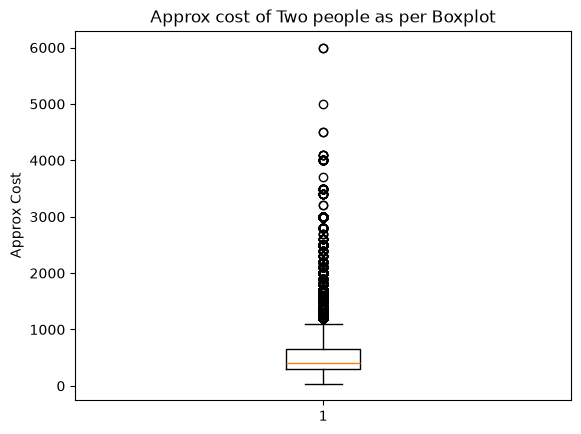

In [20]:
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\DELL\Downloads\zomato.csv\zomato.csv")
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "", regex=False)
df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

cost = df["approx_cost(for two people)"].dropna()

plt.boxplot(cost)

plt.title("Approx cost of Two people as per Boxplot")
plt.ylabel("Approx Cost")

plt.show()

In [22]:
df = pd.read_csv(
    r"C:\Users\DELL\Downloads\paytm_transactions.csv",
    sep=";"
)
df = df.rename(columns={"Amount": "transaction_amount"})
df["transaction_amount"] = pd.to_numeric(
    df["transaction_amount"],
    errors="coerce"
)
lower_limit = df["transaction_amount"].quantile(0.05)
upper_limit = df["transaction_amount"].quantile(0.95)
print("5th percentile:", lower_limit)
print("95th percentile:", upper_limit)
df["transaction_amount"] = df["transaction_amount"].clip(
    lower=lower_limit,
    upper=upper_limit
)
print("\nUpdated transaction amount statistics:")
print(df["transaction_amount"].describe())

5th percentile: 525.0
95th percentile: 885.0

Updated transaction amount statistics:
count      3.000000
mean     720.000000
std      181.865335
min      525.000000
25%      637.500000
50%      750.000000
75%      817.500000
max      885.000000
Name: transaction_amount, dtype: float64


In [28]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\flipkart_com-ecommerce_sample.csv (2)\flipkart_com-ecommerce_sample.csv")

print(df.head())
print(df.columns.tolist())
df["retail_price"] = (
    df["retail_price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

print(df["retail_price"].head())
print("Data type:", df["retail_price"].dtype)

                            uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3  0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4  bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   

                                         product_url  \
0  http://www.flipkart.com/alisha-solid-women-s-c...   
1  http://www.flipkart.com/fabhomedecor-fabric-do...   
2  http://www.flipkart.com/aw-bellies/p/itmeh4grg...   
3  http://www.flipkart.com/alisha-solid-women-s-c...   
4  http://www.flipkart.com/sicons-all-purpose-arn...   

                            product_name  \
0    Alisha Solid Women's Cycling Shorts   
1    FabHomeDecor Fabric Double Sofa Bed   
2                             AW Bellies   
3    Alisha Solid Women's Cycling Shorts   
4  Sicons All Purpose Arnica Dog Shampoo   

 

In [29]:
df = pd.DataFrame({
    "user_id": [101, 102, 103, 104, 105, 106, 107],
    "is_premium": [True, "True", 1, "yes", False, "no", 0]
})
df["is_premium"] = df["is_premium"].apply(
    lambda x: str(x).lower() in ["true", "1", "yes"]
)

print(df)
print("\nData type:")
print(df["is_premium"].dtype)

   user_id  is_premium
0      101        True
1      102        True
2      103        True
3      104        True
4      105       False
5      106       False
6      107       False

Data type:
bool
